# 1. A nasty integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp \left(-\frac{x^2}{2\sigma^2}\right) dx = 2\sigma^4 $$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)

In [131]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm

We aim to compute the integral:

$$I = \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \, dx = 2\sigma^4$$

This expression resembles a moment of the Gaussian distribution. The standard normal distribution with zero mean has the form:

$$\frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$

which integrates to 1 over the entire real line. However, since our integral is defined only over the interval $[0, \infty)$, we are effectively dealing with a half-Gaussian.

To properly normalize the distribution over this domain, we define:

$$p(x) = \frac{2}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right), \quad x \geq 0$$

This function integrates to 1 over $[0, \infty)$, making it a valid probability density function on the positive half-line.

In practice, this corresponds to sampling from a Gaussian centered at zero, then taking the **absolute value** of each sample to reflect it into the positive domain. Since this folding effectively doubles the density on $[0, \infty)$, we normalize by dividing by 2.

We can now rewrite the integral in terms of an expectation under this half-Gaussian:

$$I = \sigma\sqrt{\frac{\pi}{2}} \int_0^\infty x^3 p(x) \, dx$$

This interpretation allows us to compute the integral as a scaled moment of the half-Gaussian distribution.


### Functions:

In [132]:
def fun(x):
    """Function to integrate"""
    return x ** 3

def simulate_integral(N, mu, sigma):
    """Simulates the integral approximation using Monte Carlo method."""
    normal_factor = 0.5 * sigma * np.sqrt(2 * np.pi)  # Adjusting the normal factor
    samples = np.abs(np.random.normal(mu, sigma, N))  # Generate absolute values from a normal distribution
    integral = normal_factor * np.mean(fun(samples))  # Monte Carlo integration
    error = abs(expected_value - integral)/expected_value  # Compute absolute error
    
    return integral, error

### Convergence of the integration

In [133]:

# Parameters
Nvals = np.unique(np.logspace(0,6,100,dtype=int)) # samples
mu = 0
sigma = 2

expected_value = 2 * sigma ** 4  # Theoretical integral result for comparison

integrals = []  # Store integral estimates
scarti = []  # Store errors

# Run simulation for different sample sizes
for N in Nvals:
    integral, error = simulate_integral(N, mu, sigma)
    #print(f"Samples: {N} | Estimated Integral: {integral:.5f} | Error: {error:.5f}")
    integrals.append(integral)
    scarti.append(error)

# Convert lists to numpy arrays
integrals = np.array(integrals)
scarti = np.array(scarti)


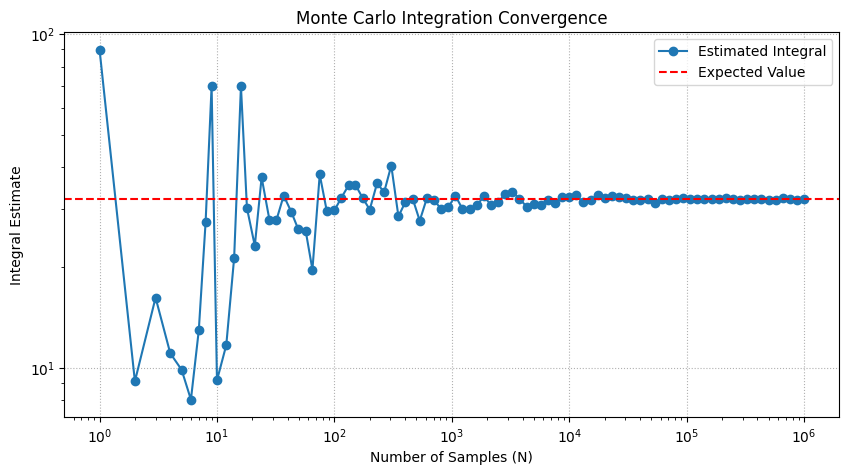

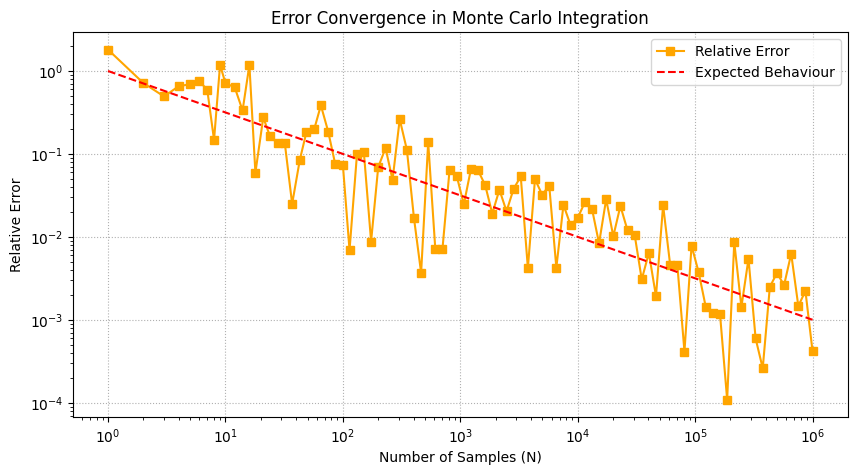

In [134]:
# Plot of estimated integrals
plt.figure(figsize=(10, 5))
plt.plot(Nvals, integrals, marker='o', label="Estimated Integral")
plt.axhline(y=expected_value, color='r', linestyle='--', label="Expected Value")
plt.xlabel("Number of Samples (N)")
plt.ylabel("Integral Estimate")
plt.title("Monte Carlo Integration Convergence")
plt.loglog()
plt.legend()
plt.grid(linestyle=':')
plt.show()

# Plot of relative error
plt.figure(figsize=(10, 5))
plt.plot(Nvals, scarti, marker='s', color='orange', label="Relative Error")
plt.plot(Nvals,  Nvals**-0.5, color='r', linestyle='--', label="Expected Behaviour" )
plt.xlabel("Number of Samples (N)")
plt.ylabel("Relative Error")
plt.title("Error Convergence in Monte Carlo Integration")
plt.legend()
plt.loglog()
plt.grid(linestyle=':')
plt.show()

The integral estimation convege to the true value and the error goes down as $1/\sqrt N$ as expected.

### Results Distribution

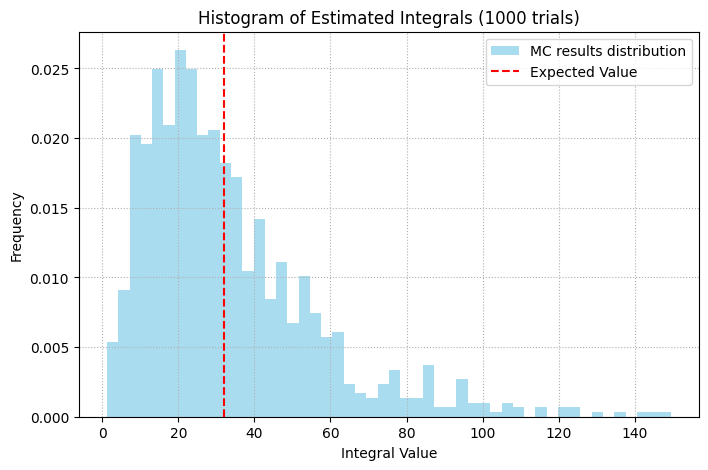

In [135]:
trial = 1000
integrale = []  # Store integral estimates

# Parameters
N = 10  # Number of samples fixed

# Run simulation for different sample sizes
for _ in range(0, trial):
    integral, error = simulate_integral(N, mu, sigma)
    #print(f"Samples: {N} | Estimated Integral: {integral:.5f}")
    integrale.append(integral)

# Convert lists to numpy arrays
integrale = np.array(integrale)

plt.figure(figsize=(8, 5))
plt.hist(integrale, bins=50, color='skyblue', density = True, alpha=0.7, label = 'MC results distribution')
plt.axvline(expected_value, color='red', linestyle='--', label='Expected Value')
plt.xlabel("Integral Value")
plt.ylabel("Frequency")
plt.title("Histogram of Estimated Integrals ({} trials)".format(trial))
plt.legend()
plt.grid(linestyle=':')
plt.show()


It looks like a poissonian. Let's see what happens if I increase the number of samples.

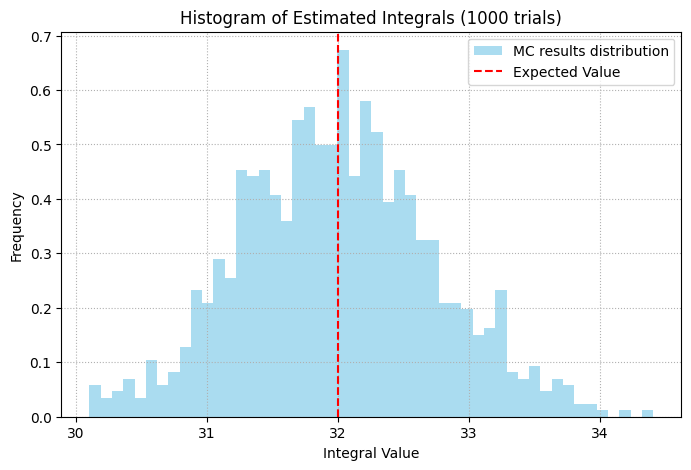

In [136]:
integrale = []  # Store integral estimates

# Parameters
N = 10000  # Number of samples fixed

# Run simulation for different sample sizes
for _ in range(0, trial):
    integral, error = simulate_integral(N, mu, sigma)
    #print(f"Samples: {N} | Estimated Integral: {integral:.5f}")
    integrale.append(integral)

# Convert lists to numpy arrays
integrale = np.array(integrale)

plt.figure(figsize=(8, 5))
plt.hist(integrale, bins=50, color='skyblue', density = True, alpha=0.7, label = 'MC results distribution')
plt.axvline(expected_value, color='red', linestyle='--', label='Expected Value')
plt.xlabel("Integral Value")
plt.ylabel("Frequency")
plt.title("Histogram of Estimated Integrals ({} trials)".format(trial))
plt.legend()
plt.grid(linestyle=':')
plt.show()

Now it looks like a Gaussian!!

### Manual Fit

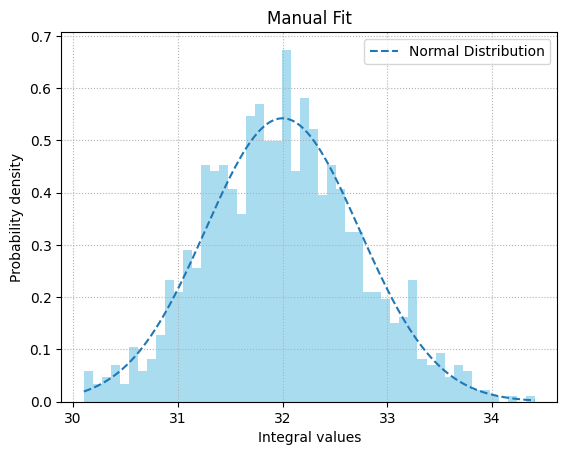

In [137]:
# estimation: 
mean = np.average(integrale)
std = np.std(integrale, ddof=1)

# --------- FITTING -----------
x = np.linspace(min(integrale), max(integrale), 1000)
norm_distr = norm.pdf(x, loc=expected_value, scale=std)

# Plot
plt.hist(integrale, bins=50, density='true' , color='skyblue', alpha=0.7)
plt.plot(x, norm_distr, color='C0', ls='--', label='Normal Distribution')
plt.xlabel('Integral values')
plt.ylabel('Probability density')
plt.legend()
plt.title('Manual Fit')
plt.grid(linestyle=':')
plt.show()

My hypothesis is that the distribution is not Gaussian for small $\textit{Ns}$ and then becomes a Gaussian in the limit for large $\textit{Ns}$. 